<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 141.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 152.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 161.0 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [3]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


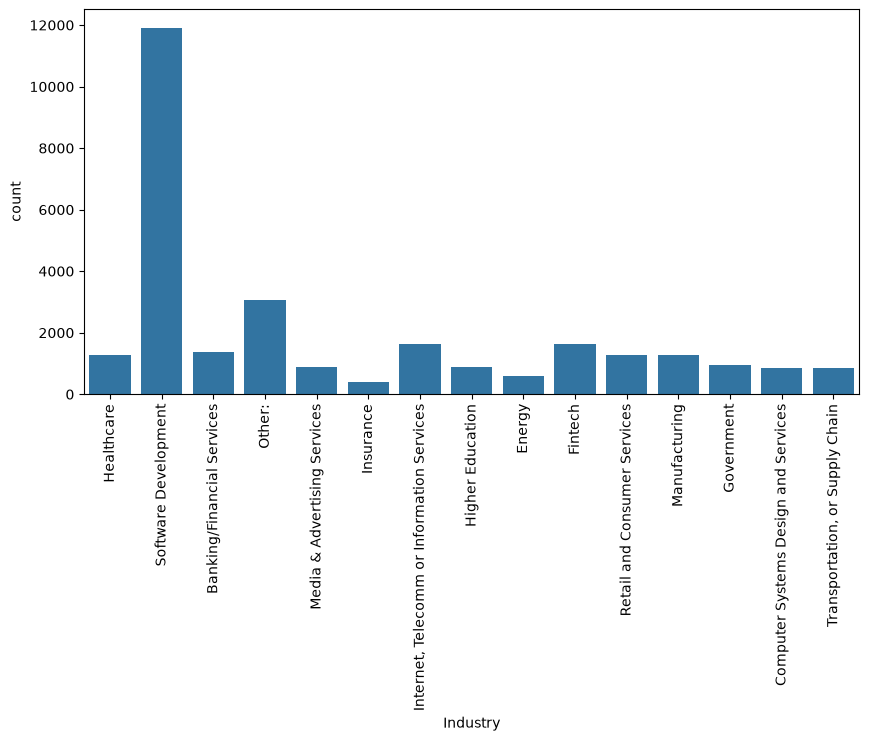

In [9]:
##Write your code here
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Industry')
plt.xticks(rotation=90)
plt.savefig("mychart.png",dpi=300,bbox_inches='tight')
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here
mean = df['ConvertedCompYearly'].mean()
median =df['ConvertedCompYearly'].median()
std = df['ConvertedCompYearly'].std()

print('Mean:', mean,'\n' 'Median:' ,median,'\n' 'Std:', std)
print( )
print('-'*5, 'Outlier Values','-'*5)
threshold = mean + (std *3)

outliers = df[df['ConvertedCompYearly']>threshold]['ConvertedCompYearly']
outliers.sort_values(ascending=False)

Mean: 86155.28726264134 
Median: 65000.0 
Std: 186756.97308629757

----- Outlier Values -----


15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
            ...    
13336      660660.0
6735       650000.0
529        650000.0
28381      650000.0
28213      650000.0
Name: ConvertedCompYearly, Length: 89, dtype: float64

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


IQR: 75259.5
Upper Bound: 220860.75
Lower Bound: -80177.25
Number of outliers using IQR: 978


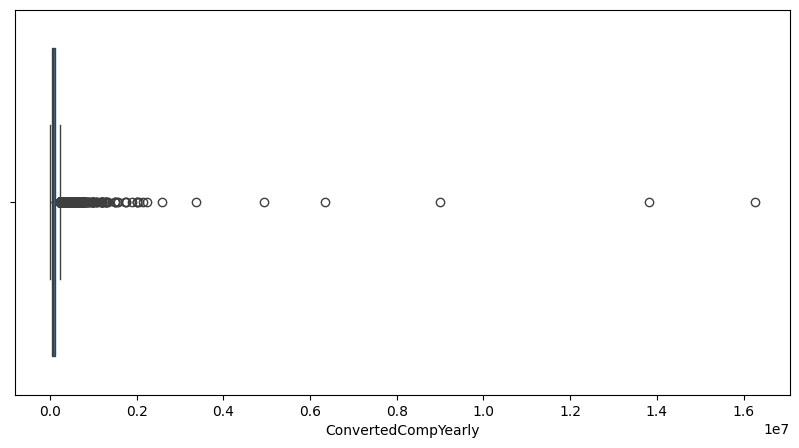

In [7]:
##Write your code here
q1 = df['ConvertedCompYearly'].quantile(0.25)
q3 = df['ConvertedCompYearly'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

iqr_outliers = df[(df['ConvertedCompYearly']<lower_bound) | (df['ConvertedCompYearly']>upper_bound)]['ConvertedCompYearly']

print(f"IQR: {IQR}")
print(f"Upper Bound: {upper_bound}")
print(f"Lower Bound: {lower_bound}")
print(f"Number of outliers using IQR: {len(iqr_outliers)}")

plt.figure(figsize=(10,5))
sns.boxplot(x=df['ConvertedCompYearly'])


plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [78]:
##Write your code here
df_cleaned =df[(df['ConvertedCompYearly']>= lower_bound) & (df['ConvertedCompYearly']<= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

print(f"New Maximum Salary: {df_cleaned['ConvertedCompYearly'].max()}")

Original rows: 65437
Cleaned rows: 22457
Rows removed: 42980
New Maximum Salary: 220207.0


In [10]:
df.skew(numeric_only=True,).round(4)

/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1279: RuntimeWarning: overflow encountered in multiply
  adjusted3 = adjusted2 * adjusted
/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1287: RuntimeWarning: overflow encountered in scalar power
  constant_tolerance3 = ((eps * max_abs) ** 3) * count
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1292: RuntimeWarning: overflow encountered in scalar power
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


ResponseId              0.0000
CompTotal                  NaN
WorkExp                 1.2417
JobSatPoints_1          1.7220
JobSatPoints_4          3.3785
JobSatPoints_5          2.7641
JobSatPoints_6          1.3919
JobSatPoints_7          1.5162
JobSatPoints_8          1.6669
JobSatPoints_9          1.9969
JobSatPoints_10         2.6387
JobSatPoints_11         2.7778
ConvertedCompYearly    52.9217
JobSat                 -1.0000
dtype: float64

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [89]:
##Write your code here
age_map={'Under 18 years old':15, 
'18-24 years old':21,   
'25-34 years old':30,  
'35-44 years old':40,
'45-54 years old':50, 
'55-64 years old':60, 
'65 years or older':70,
'Prefer not to say':None}

df_cleaned['Age_numeric'] = df_cleaned['Age'].map(age_map)

In [92]:
df_num = df_cleaned.select_dtypes(include='number')

corr_matrix = df_num.corr()

corr_matrix['Age_numeric']

ResponseId            -0.040890
CompTotal             -0.021374
WorkExp                0.842806
JobSatPoints_1        -0.038827
JobSatPoints_4        -0.070154
JobSatPoints_5        -0.096810
JobSatPoints_6        -0.051258
JobSatPoints_7        -0.084042
JobSatPoints_8        -0.051531
JobSatPoints_9        -0.084046
JobSatPoints_10       -0.112057
JobSatPoints_11       -0.106765
ConvertedCompYearly    0.371753
JobSat                 0.067045
Age_numeric            1.000000
Name: Age_numeric, dtype: float64

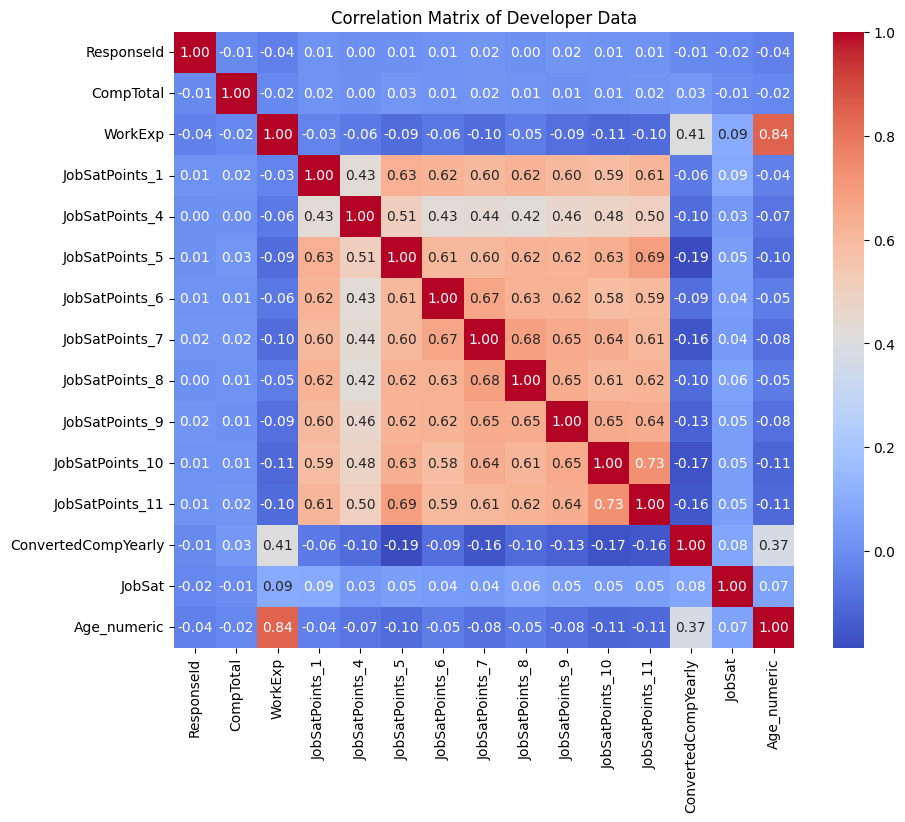

In [98]:
plt.figure(figsize=(10,8))
sns.heatmap(data=corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix of Developer Data')
plt.show()

<Axes: xlabel='Age_numeric', ylabel='WorkExp'>

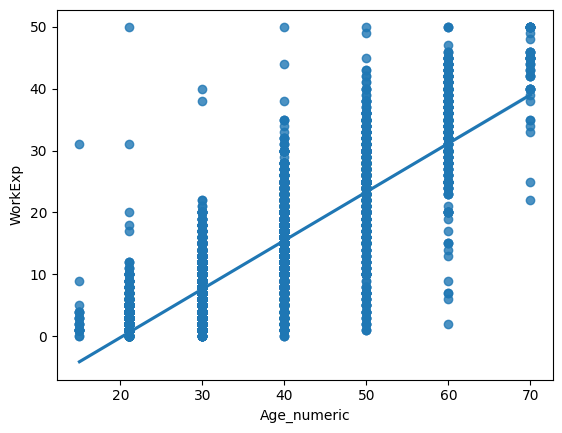

In [100]:
sns.regplot(data=df_num,x='Age_numeric',y='WorkExp')

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
